# tm_tests_xx - EDA & Preprocessing

## 0. Imports, Setup

We created specific utils file for each part of the project.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from utils_eda import (
    # constants
    LABEL_MAP, LABEL_COLORS, RANDOM_STATE,
    # data loading
    load_data, basic_info,
    # split
    make_split, load_split,
    # preprocessing functions (individual)
    remove_noise, to_lowercase, tokenize,
    remove_stopwords, lemmatize,
    stem_porter, stem_snowball,
    # preprocessing pipelines
    preprocess_lemma, preprocess_stem, preprocess_raw_clean,
    apply_preprocessing,
    # evaluation
    evaluate_model, plot_confusion_matrix, build_metrics_df,
    # EDA helpers
    plot_class_distribution, plot_tweet_length_distribution,
    plot_wordclouds, plot_top_tokens, show_preprocessing_examples,
)

In [2]:
DATA_DIR  = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

# save the train/val split pickles
SPLIT_LEMMA_PATH     = os.path.join(DATA_DIR, "train_val_split_lemma.pkl")
SPLIT_STEM_PATH      = os.path.join(DATA_DIR, "train_val_split_stem.pkl")
SPLIT_RAW_PATH       = os.path.join(DATA_DIR, "train_val_split_raw.pkl")

## 1. Data Exploration


### 1.1 Load & Basic Info

In [3]:
train_df, test_df = load_data(TRAIN_CSV, TEST_CSV)

Train shape : (9543, 2)
Test  shape : (2388, 2)


In [4]:
basic_info(train_df, "Train set")
basic_info(test_df,  "Test set")


  Train set
text     object
label     int64
dtype: object

Null values:
text     0
label    0
dtype: int64

Class distribution:
  0 (Bearish): 1442  (15.1%)
  1 (Bullish): 1923  (20.2%)
  2 (Neutral): 6178  (64.7%)

  Test set
id       int64
text    object
dtype: object

Null values:
id      0
text    0
dtype: int64


In [5]:
# Preview first rows
train_df.head(10)

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


### 1.2 Class Distribution

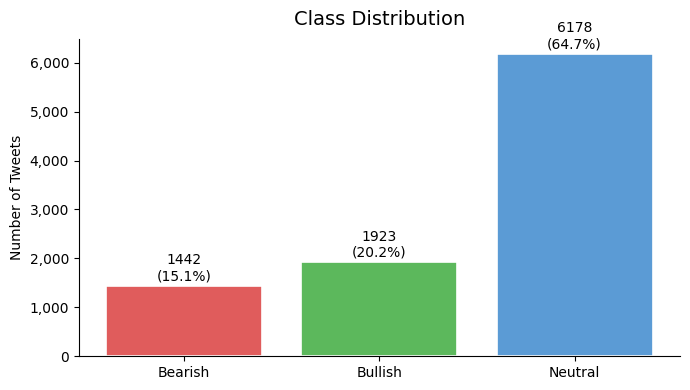

In [6]:
plot_class_distribution(train_df, label_col="label")

The majority of the dataset has as label "Neutral", showing great class imbalacement.

### 1.3 Tweet Length Distribution

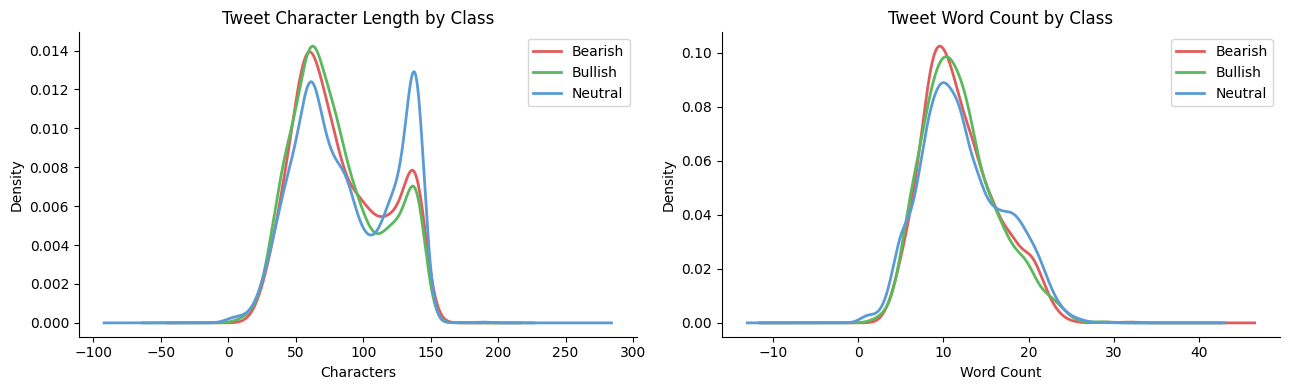

In [7]:
plot_tweet_length_distribution(train_df, text_col="text", label_col="label")

In [8]:
# Summary stats per class
train_df["char_len"]  = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df.groupby("label")[["char_len", "word_count"]].describe().round(1)

char_len                                             word_count        \
         count  mean   std   min   25%   50%    75%    max      count  mean   
label                                                                         
0       1442.0  83.3  33.0  20.0  57.2  75.5  110.8  151.0     1442.0  12.0   
1       1923.0  80.4  32.3   9.0  57.0  74.0  103.0  154.0     1923.0  11.9   
2       6178.0  88.1  36.2   2.0  59.0  82.0  125.0  190.0     6178.0  12.3   

                                        
       std  min  25%   50%   75%   max  
label                                   
0      4.3  3.0  9.0  11.0  15.0  32.0  
1      4.3  2.0  9.0  11.0  14.0  29.0  
2      4.8  1.0  9.0  12.0  16.0  29.0

We conclude that does not exist a difference between the tweet sizes and the label.

### 1.4 Word Clouds per Class

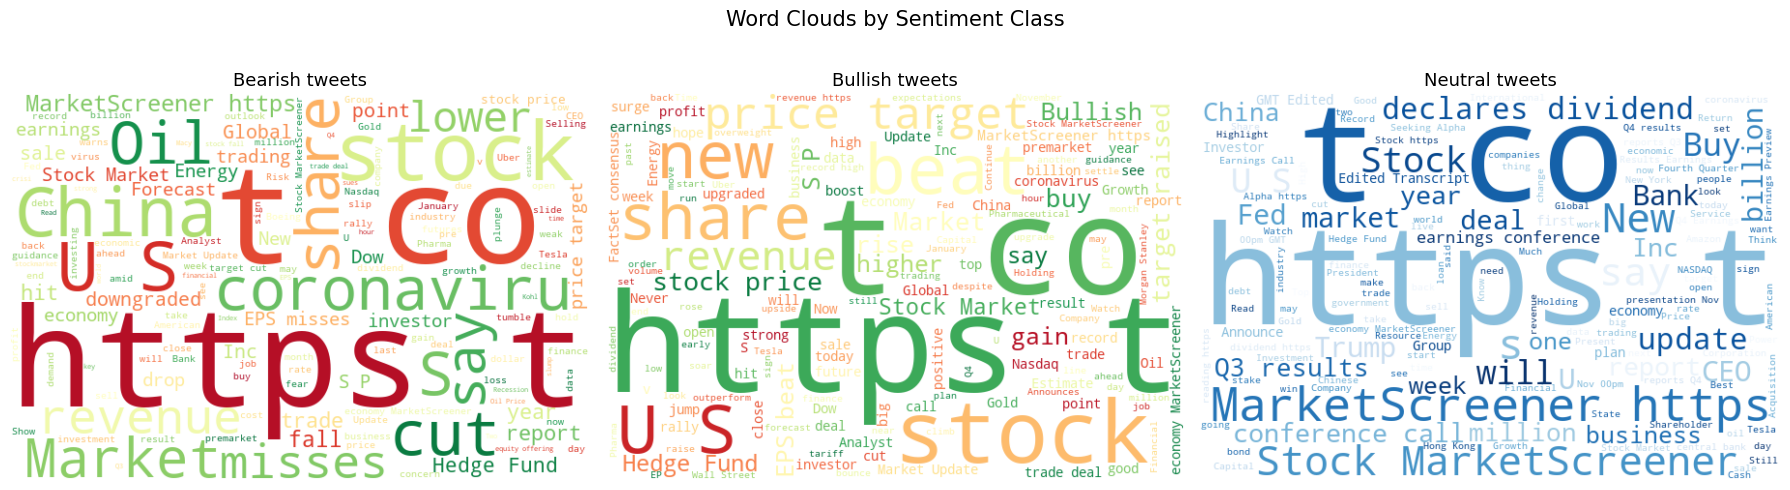

In [9]:
plot_wordclouds(train_df, text_col="text", label_col="label")

> falta

### 1.5 Top Tokens per Class (before preprocessing)

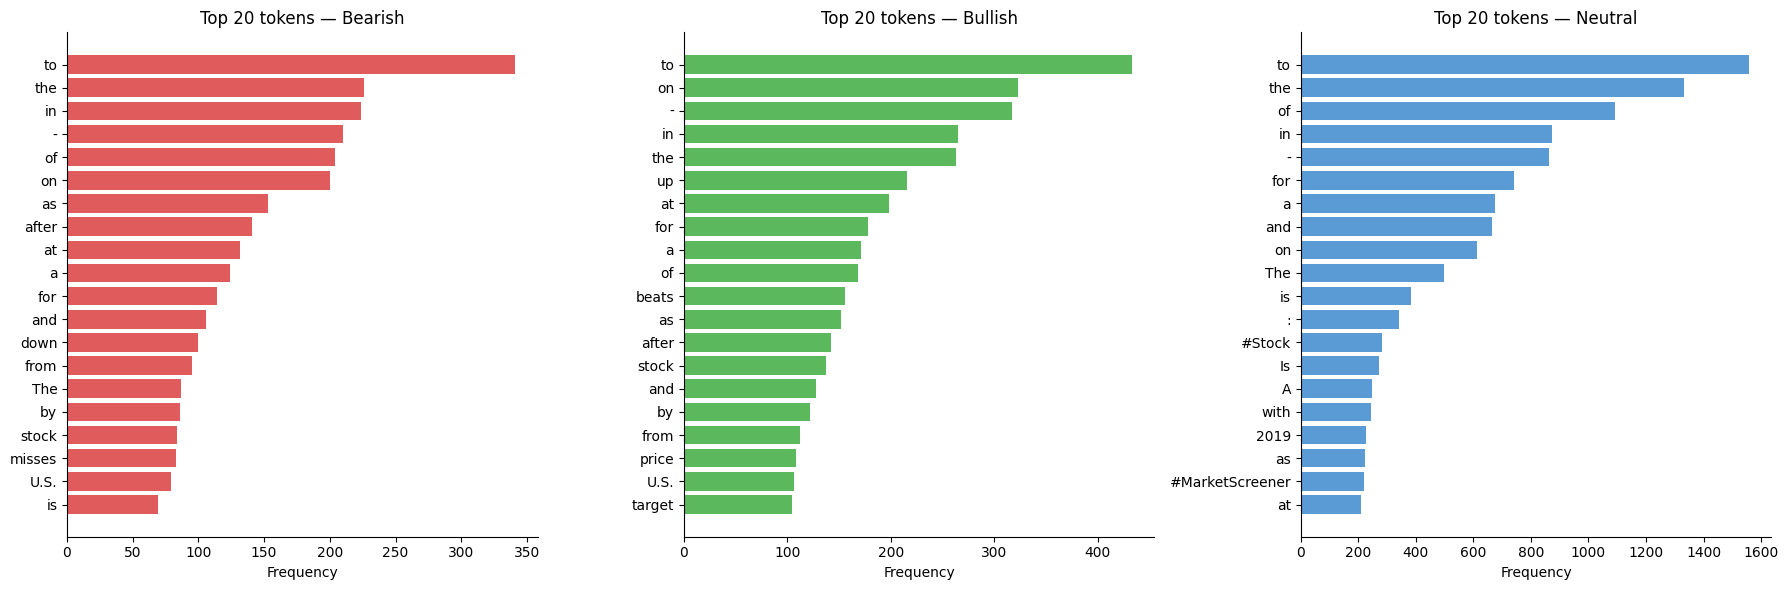

In [10]:
plot_top_tokens(train_df, text_col="text", label_col="label", n=20)

## 2. Corpus Split

We perform a **stratified 80/20 train/validation split** to preserve class proportions. The same split is saved and reused in all subsequent notebooks for consistency.

In [11]:
# We will apply preprocessing on top later for traditional ML splits
raw_split = make_split(
    train_df,
    text_col="text",
    label_col="label",
    test_size=0.2,
    save_path=SPLIT_RAW_PATH,
)

X_train_raw = raw_split["X_train"]
X_val_raw   = raw_split["X_val"]
y_train     = raw_split["y_train"]
y_val       = raw_split["y_val"]

Train size      : 7634 samples
Validation size : 1909 samples
Split saved to  : /Users/pedro/Desktop/mdsaa/2s/text_mining/project/data/train_val_split_raw.pkl


In [12]:
# Verify class proportions are preserved
print("Train class proportions:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print("\nVal class proportions:")
print((y_val.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Train class proportions:
label
0    15.1
1    20.1
2    64.7

Val class proportions:
label
0    15.1
1    20.2
2    64.7


## 3. Data Preprocessing

All techniques are implemented in `utils_eda.py`. Here we demonstrate each one individually, then build the full pipelines.

### Techniques implemented:
1. Noise Removal (Regex) — URLs, mentions, cashtags, RT markers
2. Lowercasing
3. Tokenization — TweetTokenizer
4. Stop Word Removal
5. Lemmatization (POS-aware)
6. Stemming — Porter & Snowball

### 3.1 Step-by-step Demonstration

In [13]:
example = train_df["text"].iloc[0]
print("Original:\n", example)
print()

step1 = remove_noise(example)
print("After noise removal:\n", step1)
print()

step2 = to_lowercase(step1)
print("After lowercasing:\n", step2)
print()

step3 = tokenize(step2, mode="tweet")
print("After tokenization:\n", step3)
print()

step4 = remove_stopwords(step3)
print("After stop word removal:\n", step4)
print()

step5_lemma = lemmatize(step4)
print("After lemmatization:\n", step5_lemma)
print()

step5_stem_porter   = stem_porter(step4)
step5_stem_snowball = stem_snowball(step4)
print("After Porter stemming:\n",   step5_stem_porter)
print("After Snowball stemming:\n", step5_stem_snowball)

Original:
 $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT

After noise removal:
 JPMorgan reels in expectations on Beyond Meat

After lowercasing:
 jpmorgan reels in expectations on beyond meat

After tokenization:
 ['jpmorgan', 'reels', 'in', 'expectations', 'on', 'beyond', 'meat']

After stop word removal:
 ['jpmorgan', 'reels', 'expectations', 'beyond', 'meat']

After lemmatization:
 ['jpmorgan', 'reel', 'expectation', 'beyond', 'meat']

After Porter stemming:
 ['jpmorgan', 'reel', 'expect', 'beyond', 'meat']
After Snowball stemming:
 ['jpmorgan', 'reel', 'expect', 'beyond', 'meat']


### 3.2 Before / After Examples on 5 Random Tweets

In [ ]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_lemma
)

pd.set_option("display.max_colwidth", 200) # to aid the display setting 
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from $5.50 at MKM Partners,nokia stock price target raise mkm partner
1,Russia backs OPEC+ oil output cuts,russia back opec oil output cut
2,"Many workers don't have access to retirement savings programs. Now, efforts on both a national and state level aim... https://t.co/9LNfrB1dS9",many worker access retirement saving program effort national state level aim
3,About 200 Google employees demonstrated outside the company’s San Francisco office Friday to protest the internet g… https://t.co/FZoqyx7Q9D,google employee demonstrate outside company san francisco office friday protest internet g
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT INVESTMENT REGARDING MOBILITY SERVICES PLAT... #IDG #Stock… https://t.co/32MT3bB1OC,idg energy investment voluntary announcement investment regard mobility service plat idg stock
5,"Vans parent VF Corp. says 60% of China stores are closed over coronavirus, to update guidance in May",van parent vf corp say china store close coronavirus update guidance may
6,AU Optronics reports Q4 results,au optronics report q result
7,$KZR Kezar Life Sciences Highlights Therapeutic Potential of Protein Secretion Inhibitors at the 61st American Soci… https://t.co/jFFu7R9I6T,kezar life science highlight therapeutic potential protein secretion inhibitor st american soci
8,U.S. Oil Inventories Rise More Than Expected #WTI #Stock #MarketScreener https://t.co/lMkNlbjinO https://t.co/wBBq3HdLZO,u oil inventory rise expect wti stock marketscreener
9,A Big Step Forward For the Treatment of ALS,big step forward treatment al


### 3.3 Apply Full Pipelines & Save Splits

In [21]:
# ── Pipeline A: Lemmatization ─────────────────────────────────────────────────
print("Applying lemmatization pipeline...")
X_train_lemma = apply_preprocessing(X_train_raw, pipeline="lemma")
X_val_lemma   = apply_preprocessing(X_val_raw,   pipeline="lemma")

import pickle
with open(SPLIT_LEMMA_PATH, "wb") as f:
    pickle.dump({
        "X_train": X_train_lemma, "X_val": X_val_lemma,
        "y_train": y_train,       "y_val": y_val,
    }, f)
print(f"Saved → {SPLIT_LEMMA_PATH}")

Applying lemmatization pipeline...
Saved → /Users/pedro/Desktop/mdsaa/2s/text_mining/project/data/train_val_split_lemma.pkl


In [22]:
# ── Pipeline B: Porter Stemming ───────────────────────────────────────────────
print("Applying Porter stemming pipeline...")
X_train_stem = apply_preprocessing(X_train_raw, pipeline="stem_porter")
X_val_stem   = apply_preprocessing(X_val_raw,   pipeline="stem_porter")

with open(SPLIT_STEM_PATH, "wb") as f:
    pickle.dump({
        "X_train": X_train_stem, "X_val": X_val_stem,
        "y_train": y_train,      "y_val": y_val,
    }, f)
print(f"Saved → {SPLIT_STEM_PATH}")

Applying Porter stemming pipeline...
Saved → /Users/pedro/Desktop/mdsaa/2s/text_mining/project/data/train_val_split_stem.pkl


### 3.4 Top Tokens After Preprocessing

Compare the top tokens before and after — confirms noise removal and stop word filtering worked.

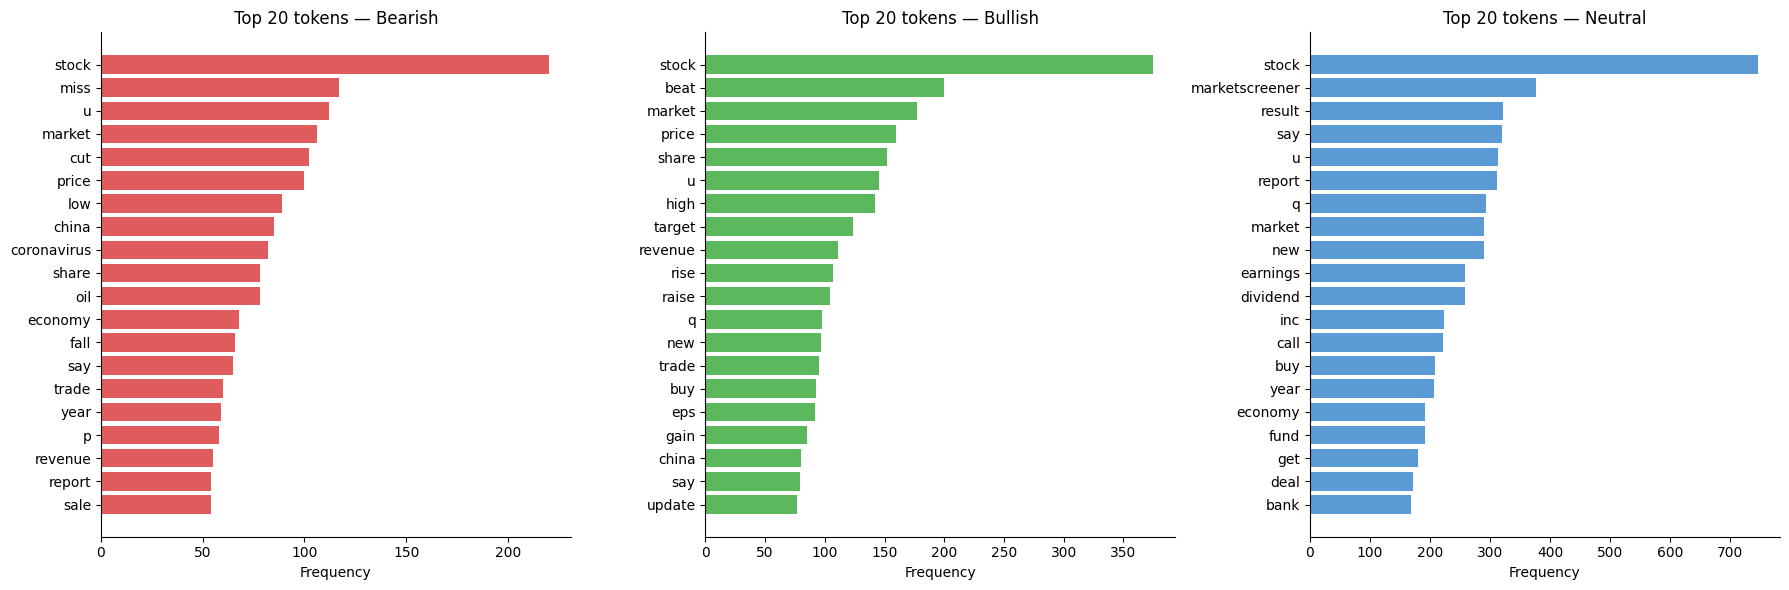

In [17]:
# Build a temporary df with preprocessed text for the full train set (for visualization only)
train_df["text_lemma"] = apply_preprocessing(train_df["text"], pipeline="lemma")

plot_top_tokens(train_df, text_col="text_lemma", label_col="label", n=20)

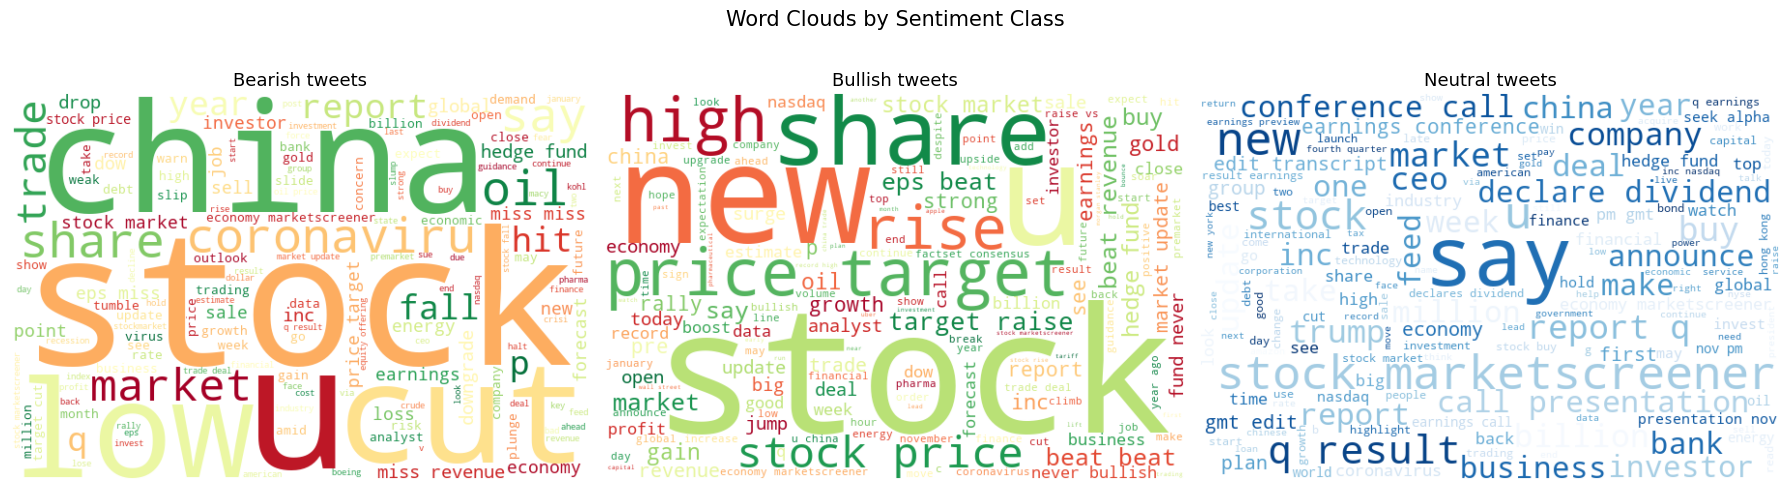

In [18]:
# Word clouds after preprocessing
plot_wordclouds(train_df, text_col="text_lemma", label_col="label")

We can see that now, the word clouds are way more well defined:
- **"Bearish" label** now contains "china", "low" and "cut" as frequent words
- **Bullish** has "high", "rise", "new", which make a lot of sense


### Saved Artifacts
| File | Description | Used by |
|---|---|---|
| `train_val_split_raw.pkl` | Raw text, stratified 80/20 | Transformer notebooks |
| `train_val_split_lemma.pkl` | Lemmatized text, same split | BoW / Word2Vec notebooks |
| `train_val_split_stem.pkl` | Porter-stemmed text, same split | BoW / Word2Vec notebooks |